### prep chai array-like

In [39]:
import pandas as pd
import yaml
from pathlib import Path

YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/mcmahon_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CSV_PATH =  (OUTPUT_DIR / "merged_mcmahon.csv")
scores_df = pd.read_csv(CSV_PATH)

scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,1.031273,0.931017,0.821457,0.3654,0.9208,0.4745,"[[0.8947316408157349, 0.8773423433303833]]","[[[0.8947316408157349, 0.18504926562309265], [...","[[0.9116538166999817, 0.883705198764801]]","[[[0.9116538166999817, 0.6726003289222717], [0..."
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,9.585999,0.454871,0.105424,0.3059,0.0374,0.0189,"[[0.8954976201057434, 0.8623983263969421]]","[[[0.8954976201057434, 0.16813652217388153], [...","[[0.8860877752304077, 0.8743113279342651]]","[[[0.8860877752304077, 0.6033287048339844], [0..."
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,1.967852,0.928613,0.819429,0.5921,0.7323,0.5462,"[[0.8845064640045166, 0.8698375821113586]]","[[[0.8845064640045166, 0.2977530360221863], [0...","[[0.8777276873588562, 0.8784562945365906]]","[[[0.8777276873588562, 0.6706950664520264], [0..."
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,4.794119,0.632155,0.268686,0.2883,0.0783,0.2570,"[[0.8772791624069214, 0.8879954814910889]]","[[[0.8772791624069214, 0.1704052984714508], [0...","[[0.8828604221343994, 0.8691251873970032]]","[[[0.8828604221343994, 0.28181707859039307], [..."
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,4.983984,0.552838,0.212057,0.1630,0.0450,0.1986,"[[0.8713318109512329, 0.8909714221954346]]","[[[0.8713318109512329, 0.1788160502910614], [0...","[[0.8764632344245911, 0.8797900676727295]]","[[[0.8764632344245911, 0.3389747738838196], [0..."


### prep chai array-like

In [40]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)
#chai_df.head()

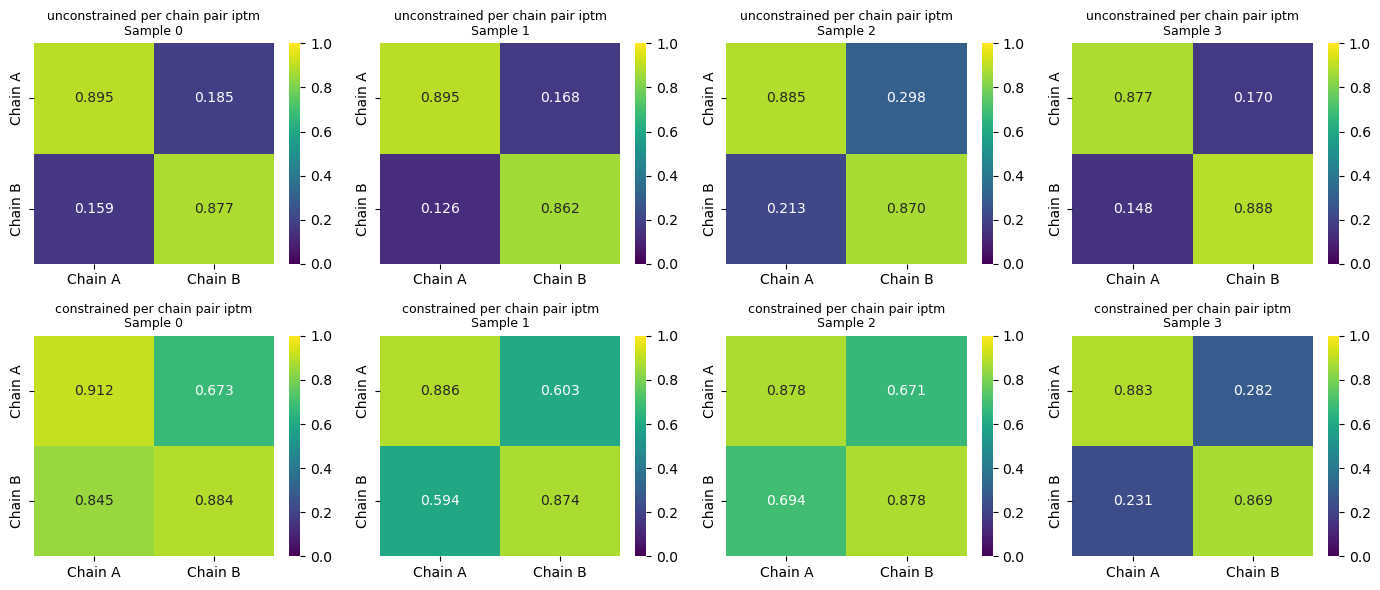

In [41]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [42]:
def extract_matrix_min(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # germinal/mcmahon: only one interface (A-C or B-C)
    if n == 2:
        return np.min([matrix[0, 1], matrix[1, 0]])

    # snir: average C interactions with A and B
    elif n == 3:
        ac = np.min([matrix[0, 2], matrix[2, 0]])
        bc = np.min([matrix[1, 2], matrix[2, 1]])
        return np.min([ac, bc])

    return np.nan

chai_df['chai_unconstrained_per_chain_pair_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)

chai_df['chai_constrained_per_chain_pair_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_min)


# Display summary
print("Unconstrained A-B interface min (top 10):")
print(chai_df['chai_unconstrained_per_chain_pair_iptm'].head(10).to_string())
print("\nConstrained A-B interface min (top 10):")
print(chai_df['chai_constrained_per_chain_pair_iptm'].head(10).to_string())

Unconstrained A-B interface min (top 10):
0    0.158522
1    0.126453
2    0.213046
3    0.147860
4    0.164553
5    0.221979
6    0.205942
7    0.133280
8    0.206422
9    0.126306

Constrained A-B interface min (top 10):
0    0.672600
1    0.594245
2    0.670695
3    0.231424
4    0.314370
5    0.574162
6    0.306226
7    0.240449
8    0.281632
9    0.403806


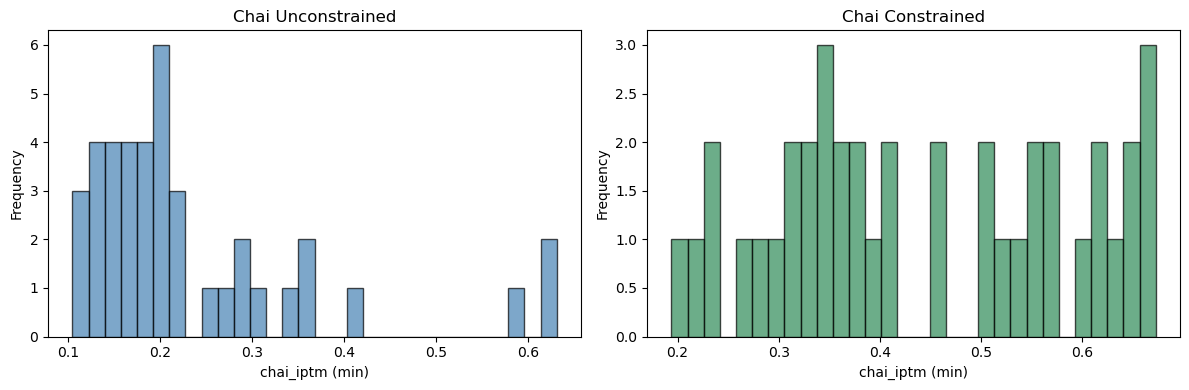

In [43]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_iptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_pair_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_iptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_iptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [44]:
# Extract min pTM
def extract_ptm_min(arr):
    """Extract minimum of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.min(arr)

# Extract min for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Extract min for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_min)

# Display summary

print("\nUnconstrained pTM min (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM min (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM min - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM min - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")


Unconstrained pTM min (top 10):
0    0.877342
1    0.862398
2    0.869838
3    0.877279
4    0.871332
5    0.890785
6    0.890199
7    0.855968
8    0.853398
9    0.855640

Constrained pTM min (top 10):
0    0.883705
1    0.874311
2    0.877728
3    0.869125
4    0.876463
5    0.878004
6    0.873632
7    0.858820
8    0.860487
9    0.864959

Unconstrained pTM min - desc stats:
count    40.000000
mean      0.863996
std       0.016112
min       0.839375
25%       0.851507
50%       0.859803
75%       0.877295
max       0.890785
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM min - desc stats:
count    40.000000
mean      0.868797
std       0.012691
min       0.840910
25%       0.860889
50%       0.865869
75%       0.877797
max       0.895686
Name: chai_constrained_per_chain_ptm, dtype: float64


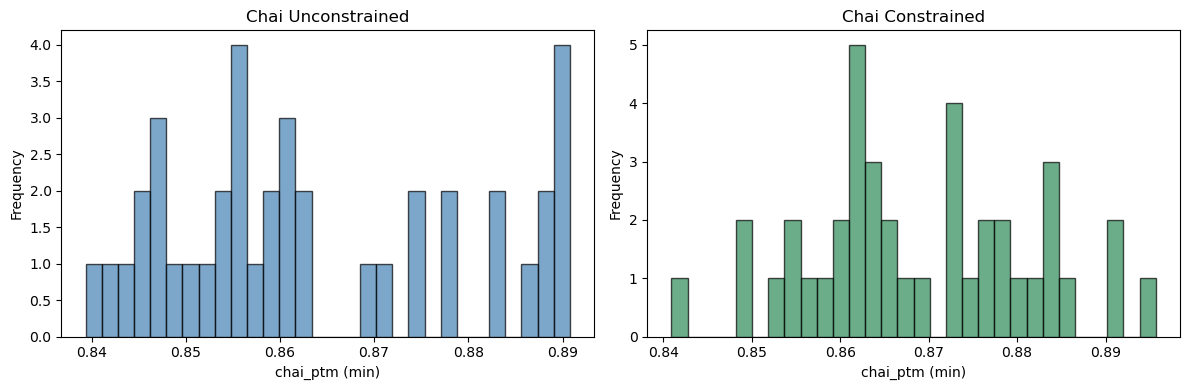

In [45]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('chai_ptm (min)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Chai Unconstrained')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_ptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('chai_ptm (min)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Chai Constrained')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ptm_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# Create df_chai_numeric with extracted mean scores 
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_pair_iptm',
                            'chai_constrained_per_chain_pair_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (40, 5)

df_chai_numeric head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0   Nb.b201_HSA_404-609                          0.877342                        0.883705                                0.158522                              0.672600
1   Nb.b201_HSA_404-601                          0.862398                        0.874311                                0.126453                              0.594245
2    Nb.b201_HSA_25-609                          0.869838                        0.877728                                0.213046                              0.670695
3  Nb.AQ100_Adiponectin                          0.877279                        0.869125                                0.147860                              0.231424
4  Nb.AQ101_Adiponectin                          0.871332                        0.876463                 

In [47]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,0.931017,0.960596,0.967690,0.397084,1.031273,0.931017,0.821457,0.3654,0.9208,0.4745
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,0.454871,0.958731,0.951999,0.722696,9.585999,0.454871,0.105424,0.3059,0.0374,0.0189
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,0.928613,0.956107,0.952910,0.336298,1.967852,0.928613,0.819429,0.5921,0.7323,0.5462
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,0.632155,0.846693,0.778371,1.124231,4.794119,0.632155,0.268686,0.2883,0.0783,0.2570
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,0.552838,0.809803,0.728891,1.135794,4.983984,0.552838,0.212057,0.1630,0.0450,0.1986


In [48]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (40, 91)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

scores_df_extended head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_pair_iptm  chai_constrained_per_chain_pair_iptm
0   Nb.b201_HSA_404-609                          0.877342                        0.883705                                0.158522                              0.672600
1   Nb.b201_HSA_404-601                          0.862398                        0.874311                                0.126453                              0.594245
2    Nb.b201_HSA_25-609                          0.869838                        0.877728                                0.213046                              0.670695
3  Nb.AQ100_Adiponectin                          0.877279                  

In [49]:
scores_df_extended.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_pair_iptm
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,1.031273,0.931017,0.821457,0.3654,0.9208,0.4745,0.877342,0.883705,0.158522,0.672600
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,9.585999,0.454871,0.105424,0.3059,0.0374,0.0189,0.862398,0.874311,0.126453,0.594245
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,1.967852,0.928613,0.819429,0.5921,0.7323,0.5462,0.869838,0.877728,0.213046,0.670695
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,4.794119,0.632155,0.268686,0.2883,0.0783,0.2570,0.877279,0.869125,0.147860,0.231424
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,4.983984,0.552838,0.212057,0.1630,0.0450,0.1986,0.871332,0.876463,0.164553,0.314370
